In [38]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams["xtick.direction"] = "in"
matplotlib.rcParams["ytick.direction"] = "in"
plt.rcParams['xtick.major.size'] = 2  # Length of major ticks
plt.rcParams['ytick.major.size'] = 2  # Length of major ticks
plt.rcParams['xtick.minor.size'] = 1  # Length of minor ticks
plt.rcParams['ytick.minor.size'] = 1  # Length of minor ticks

In [8]:
def steinhart(R, A, B, C):
    """
    Calculate the temperature in Celsius from the resistance of a thermistor using the Steinhart-Hart equation.

    Parameters:
    R (float): Resistance of the thermistor in ohms.
    A (float): Steinhart-Hart coefficient A.
    B (float): Steinhart-Hart coefficient B.
    C (float): Steinhart-Hart coefficient C.

    Returns:
    float: Temperature in Celsius.
    """

    # Calculate the natural logarithm of the resistance
    lnR = np.log(R)

    # Apply the Steinhart-Hart equation
    inv_T = A + B * lnR + C * (lnR ** 3)

    # Convert from Kelvin to Celsius
    T_Celsius = (1 / inv_T) - 273.15

    return T_Celsius

In [10]:
def func(R, A, B, C, T):
    """
    Function to be used with fsolve to find the resistance corresponding to a given temperature.

    Parameters:
    R (float): Resistance of the thermistor in ohms.
    A (float): Steinhart-Hart coefficient A.
    B (float): Steinhart-Hart coefficient B.
    C (float): Steinhart-Hart coefficient C.
    T (float): Temperature in Celsius.

    Returns:
    float: The difference between the calculated temperature and the target temperature.
    """
    return steinhart(R, A, B, C) - T

In [46]:
a = 7.96e-4
b = 2.14e-4
c = 6.58e-8
root = fsolve(func, args=(a, b, c, 350), x0=100)
root

array([43.0699])

In [24]:
from scipy.optimize import curve_fit
import pandas as pd

In [47]:
sh = pd.read_csv("~/Documents/sh.csv")

In [48]:
sh

,d1,d2,d3,R
0,195,200.0,199.5,440.17
1,212,221.0,220.0,298.59
2,244,252.0,251.5,175.93
3,278,286.0,287.0,109.54
4,317,325.0,327.0,71.50
5,391,NaN,NaN,43.07


In [27]:
popt, pcov = curve_fit(steinhart, sh["R"], sh["d1"], p0=[a, b, c])

In [ ]:
popt

array([ 1.93076491e-04,  3.82841636e-04, -1.71130693e-06])

d1: [array([310.24240981]), array([119.64693759]), array([71.94779604])]


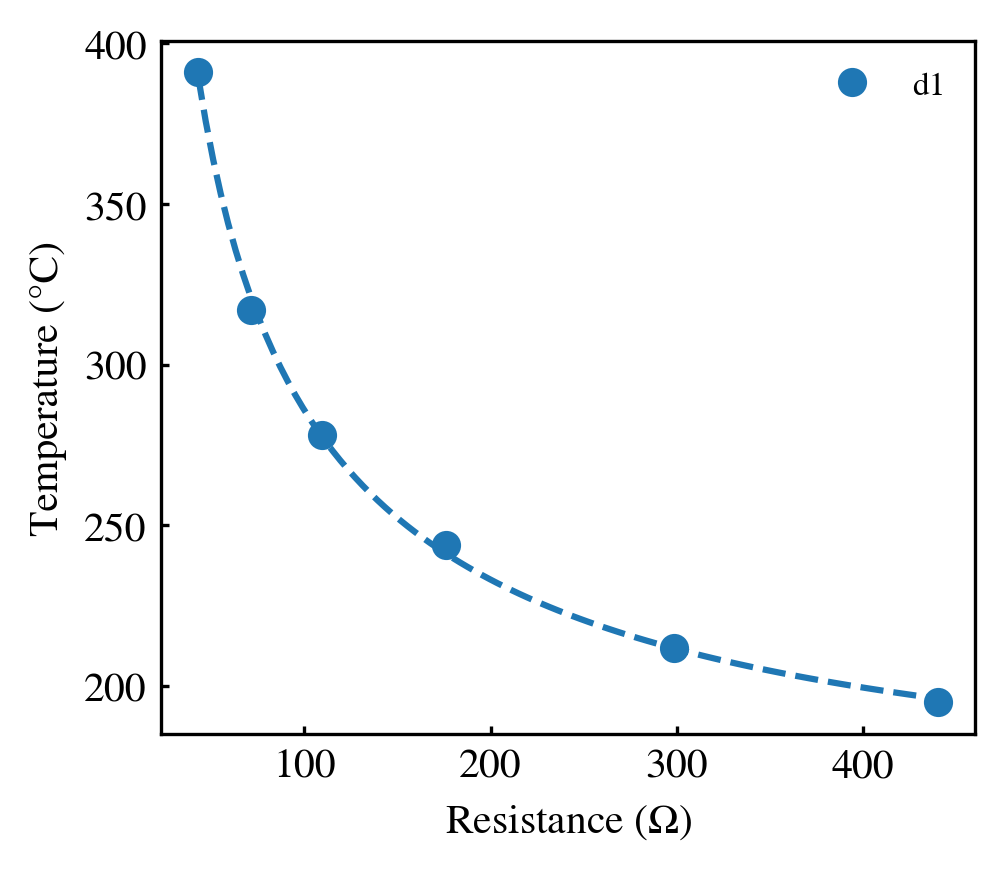

In [56]:
R = np.linspace(min(sh["R"]), max(sh["R"]), 100)
i = 0
typical_temp = np.array([210, 270, 320])
cmap = plt.get_cmap("tab10")
plt.figure(figsize=(3.5, 3), dpi=300)
for d in ["d1"]:
    plt.plot(sh["R"], sh[d], "o", label=d, color=cmap(i))
    popt, pcov = curve_fit(steinhart, sh["R"], sh[d], p0=[a, b, c])
    plt.plot(R, steinhart(R, *popt), ls="--", color=cmap(i))
    res_list = []
    for T in typical_temp:
        res = fsolve(func, args=(*popt, T), x0=100)
        res_list.append(res)
    print(f"{d}: {res_list}")
    i += 1
plt.xlabel("Resistance ($\\Omega$)")
plt.ylabel("Temperature (°C)")

plt.legend(frameon=False, fontsize=8)